# 05 — Bike Utilisation & Retirement Risk
**Question:** Which bikes are over-worked and potentially unsafe due to missing maintenance records?

Key finding: Bike #12942 — 8,197 rentals, 7.7 years, 2,810 hours ridden, zero workshop records.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

PROJECT = 'm2-dataset-study'

client = bigquery.Client(project=PROJECT)

def bq(sql):
    return client.query(sql, location='EU').to_dataframe()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['figure.titlesize'] = 28
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlepad'] = 20

## 5.1 — Distribution of total rentals per bike

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


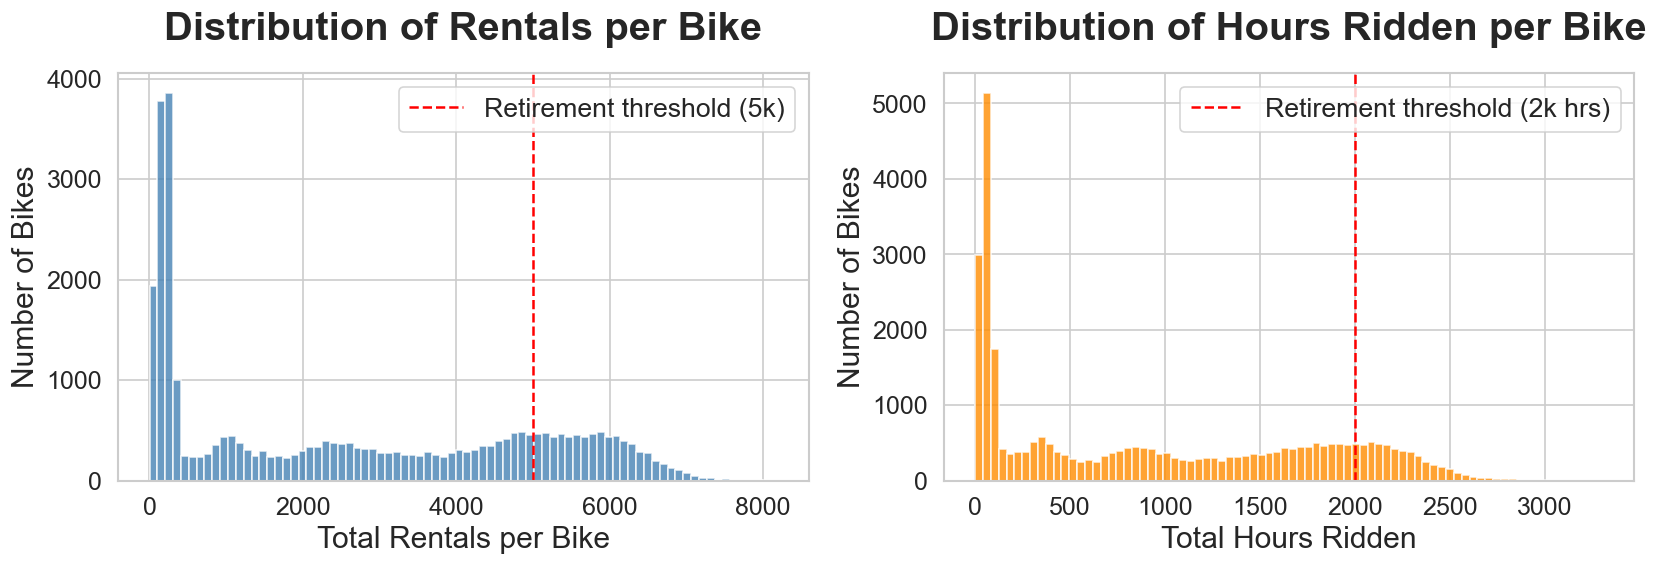

Total bikes: 31,833
Exceed retirement threshold: 7,220
HIGH RISK (threshold + no maintenance record): 6,502


In [2]:
sql = """
SELECT
    bike_id,
    total_rentals,
    total_hours_ridden,
    avg_rentals_per_day,
    active_lifespan_days,
    has_workshop_record,
    exceeds_retirement_threshold,
    is_high_risk_no_maintenance,
    model_category
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_bike_utilisation`
WHERE bike_id IS NOT NULL
"""
df = bq(sql)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rental count distribution
ax = axes[0]
ax.hist(df['total_rentals'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(5000, color='red', linestyle='--', linewidth=1.5, label='Retirement threshold (5k)')
ax.set_xlabel('Total Rentals per Bike')
ax.set_ylabel('Number of Bikes')
ax.set_title('Distribution of Rentals per Bike', fontsize=24, fontweight='bold')
ax.legend()

# Hours ridden distribution
ax2 = axes[1]
ax2.hist(df['total_hours_ridden'].dropna(), bins=80, color='darkorange', edgecolor='white', alpha=0.8)
ax2.axvline(2000, color='red', linestyle='--', linewidth=1.5, label='Retirement threshold (2k hrs)')
ax2.set_xlabel('Total Hours Ridden')
ax2.set_ylabel('Number of Bikes')
ax2.set_title('Distribution of Hours Ridden per Bike', fontsize=24, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/05_utilisation_distribution.png', bbox_inches='tight')
plt.show()

print(f"Total bikes: {len(df):,}")
print(f"Exceed retirement threshold: {df['exceeds_retirement_threshold'].sum():,}")
print(f"HIGH RISK (threshold + no maintenance record): {df['is_high_risk_no_maintenance'].sum():,}")

## 5.2 — Top 15 hardest-working bikes

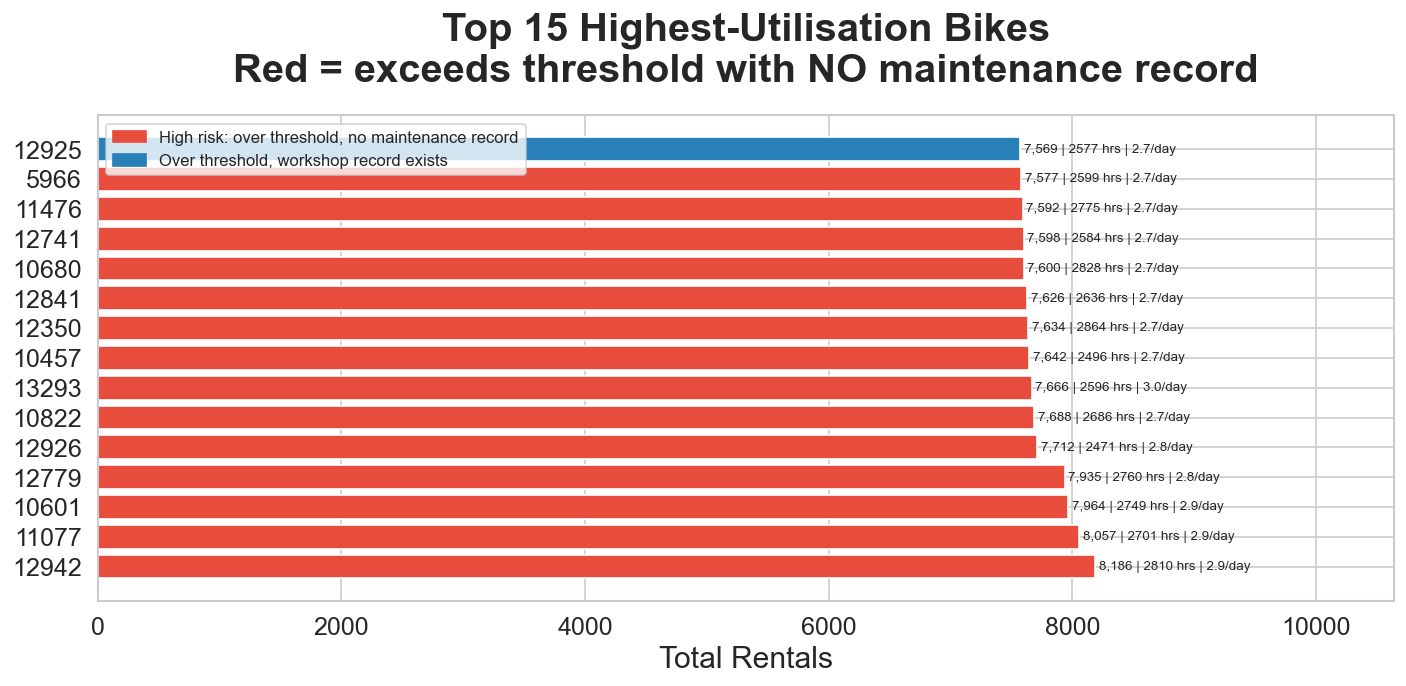

 bike_id  total_rentals  total_hours_ridden  avg_rentals_per_day  active_lifespan_days  has_workshop_record  is_high_risk_no_maintenance
   12942           8186              2810.4                  2.9                  2800                False                         True
   11077           8057              2701.2                  2.9                  2805                False                         True
   10601           7964              2748.6                  2.9                  2719                False                         True
   12779           7935              2760.1                  2.8                  2805                False                         True
   12926           7712              2471.3                  2.8                  2791                False                         True
   10822           7688              2685.5                  2.7                  2802                False                         True
   13293           7666              2596

In [3]:
top15 = df.nlargest(15, 'total_rentals')[[
    'bike_id','total_rentals','total_hours_ridden',
    'avg_rentals_per_day','active_lifespan_days',
    'has_workshop_record','is_high_risk_no_maintenance'
]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
colours = ['#E74C3C' if risk else '#2980B9' for risk in top15['is_high_risk_no_maintenance']]
bars = ax.barh(top15['bike_id'].astype(str), top15['total_rentals'], color=colours)
ax.set_xlabel('Total Rentals')
ax.set_title('Top 15 Highest-Utilisation Bikes\nRed = exceeds threshold with NO maintenance record',
             fontsize=24, fontweight='bold')

for bar, row in zip(bars, top15.itertuples()):
    label = f"{row.total_rentals:,} | {row.total_hours_ridden:.0f} hrs | {row.avg_rentals_per_day}/day"
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8)

ax.set_xlim(right=top15['total_rentals'].max() * 1.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E74C3C', label='High risk: over threshold, no maintenance record'),
    Patch(color='#2980B9', label='Over threshold, workshop record exists'),
], fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/05_top_bikes.png', bbox_inches='tight')
plt.show()
print(top15.to_string(index=False))

## 5.3 — Maintenance trip analysis

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Maintenance Trip Summary:
      workshop_name maintenance_duration_bucket  trips  avg_hours  max_days
   Clapham Workshop              short_term_1d+    431       85.5       7.0
   Clapham Workshop             medium_term_7d+    249      303.6      29.3
   Clapham Workshop                    same_day     94       11.0       1.0
   Clapham Workshop              long_term_30d+      3     1351.0      64.0
Electrical Workshop                    same_day      1        0.3       0.0
Electrical Workshop             medium_term_7d+      1      356.6      14.9
    Penton Workshop              short_term_1d+    387       82.7       6.9
    Penton Workshop             medium_term_7d+    201      296.7      27.4
    Penton Workshop                    same_day    134        9.3       1.0
    Penton Workshop              long_term_30d+      2     1168.2      57.8


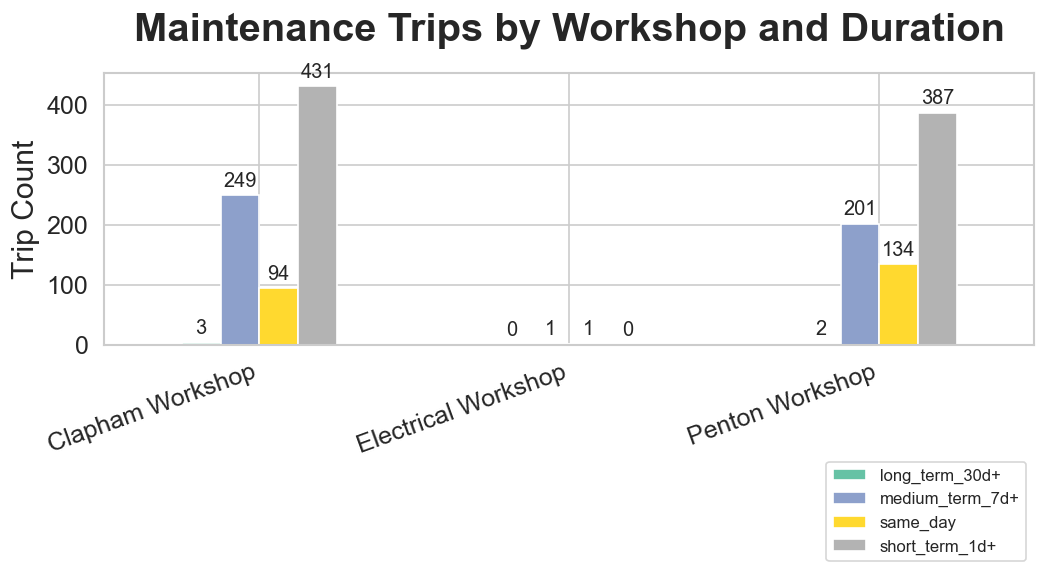

In [19]:
maint_sql = """
SELECT
    workshop_name,
    maintenance_duration_bucket,
    COUNT(*) AS trips,
    ROUND(AVG(duration_hours), 1) AS avg_hours,
    ROUND(MAX(duration_days), 1) AS max_days
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_maintenance_trips`
GROUP BY workshop_name, maintenance_duration_bucket
ORDER BY workshop_name, trips DESC
"""
maint = bq(maint_sql)
print("Maintenance Trip Summary:")
print(maint.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
pivot = maint.groupby(['workshop_name','maintenance_duration_bucket'])['trips'].sum().unstack(fill_value=0)
pivot.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Maintenance Trips by Workshop and Duration', fontsize=24, fontweight='bold')
ax.set_ylabel('Trip Count')
ax.set_xlabel('')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=12)

ax.legend(loc='upper right', bbox_to_anchor=(1, -0.4), ncol=1, fontsize=10)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../outputs/05_maintenance_breakdown.png', bbox_inches='tight')
plt.show()